In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
tf.__version__

'2.19.0'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
train_datagen = ImageDataGenerator(rescale=1./255, shear_range= 0.2, zoom_range=0.2, horizontal_flip=True)

training_set = train_datagen.flow_from_directory("/content/drive/MyDrive/Dataset/TrainingDataset", target_size=(128,128), batch_size=32, class_mode="binary")

Found 50 images belonging to 2 classes.


In [7]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_set = test_datagen.flow_from_directory("/content/drive/MyDrive/Dataset/TestingDataset", target_size=(128,128), batch_size=32, class_mode="binary")

Found 50 images belonging to 2 classes.


In [8]:
cnn = tf.keras.models.Sequential()

In [ ]:
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=[128,128,3]))

In [9]:
cnn.add(tf.keras.layers.Flatten())

In [10]:
cnn.add(tf.keras.layers.Dense(units=128, activation="relu"))

In [11]:
cnn.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

In [12]:
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [13]:
cnn.fit(x=training_set, validation_data=test_set, epochs=30)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 24s 20s/step - accuracy: 0.5400 - loss: 16.1333 - val_accuracy: 0.5000 - val_loss: 6.2918
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.5800 - loss: 5.8231 - val_accuracy: 0.5800 - val_loss: 2.7627
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.6600 - loss: 1.9830 - val_accuracy: 0.9800 - val_loss: 0.1308
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.7800 - loss: 2.5709 - val_accuracy: 0.9200 - val_loss: 0.2661
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.8400 - loss: 0.5777 - val_accuracy: 0.8400 - val_loss: 1.0696
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7800 - loss: 1.4209 - val_accuracy: 0.9200 - val_loss: 0.3806
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.8800 - loss: 1.3150 - val_accuracy: 0.9000 - val_loss: 0.5899
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.9000 - loss: 1.3225 - val_accuracy: 0.8600 - val_loss: 1.3540
Epoch 9/30
2/

In [14]:
loss, accuracy = cnn.evaluate(test_set)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - accuracy: 0.9800 - loss: 0.0414
Test loss: 0.04142022132873535
Test accuracy: 0.9800000190734863


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step


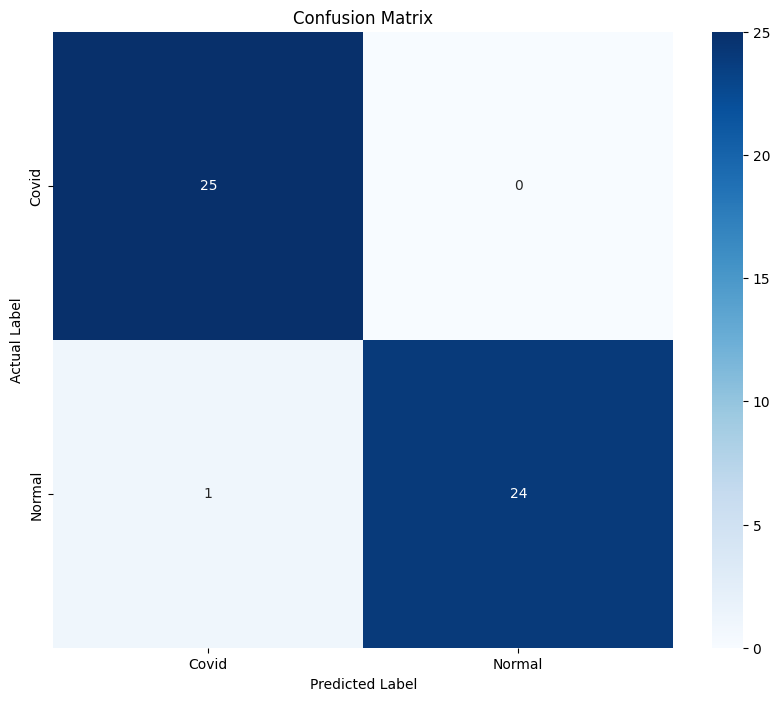

              precision    recall  f1-score   support

       Covid       0.96      1.00      0.98        25
      Normal       1.00      0.96      0.98        25

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

test_set.reset()
test_set.shuffle = False

predictions = cnn.predict(test_set)
# For binary classification with sigmoid output, apply a threshold (e.g., 0.5)
y_pred = (predictions > 0.5).astype(int)

y_true = test_set.classes
class_names = list(test_set.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 6. Detailed Performance Report
print(classification_report(y_true, y_pred, target_names=class_names))

In [15]:
print(training_set.class_indices)

{'Covid': 0, 'Normal': 1}


In [25]:
image_path = 'image.jpg'

In [26]:
import numpy as np
from tensorflow.keras.preprocessing import image
test_image = image.load_img(image_path, target_size = (128, 128))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0] == 1:
  prediction = 'Normal'
else:
  prediction = 'Covid'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [27]:
print(prediction)

Covid


In [32]:
import numpy as np
from tensorflow.keras.preprocessing import image
image_path = '/content/dataset-card.jpg'
test_image = image.load_img(image_path, target_size = (128, 128))
test_image = image.img_to_array(test_image)
test_image = np.expand_dims(test_image, axis = 0)
result = cnn.predict(test_image)
training_set.class_indices
if result[0][0] == 1:
  prediction = 'Normal'
else:
  prediction = 'Covid'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [33]:
print(prediction)

Covid


In [34]:
# Saves everything (Architecture, Weights, and Optimizer state)
cnn.save("covid_model.keras")
print("Saved model to disk")

Saved model to disk
